N          : 50
Mean       : 130.6000
Variance   : 5260.7600
Std Dev    : 72.5311


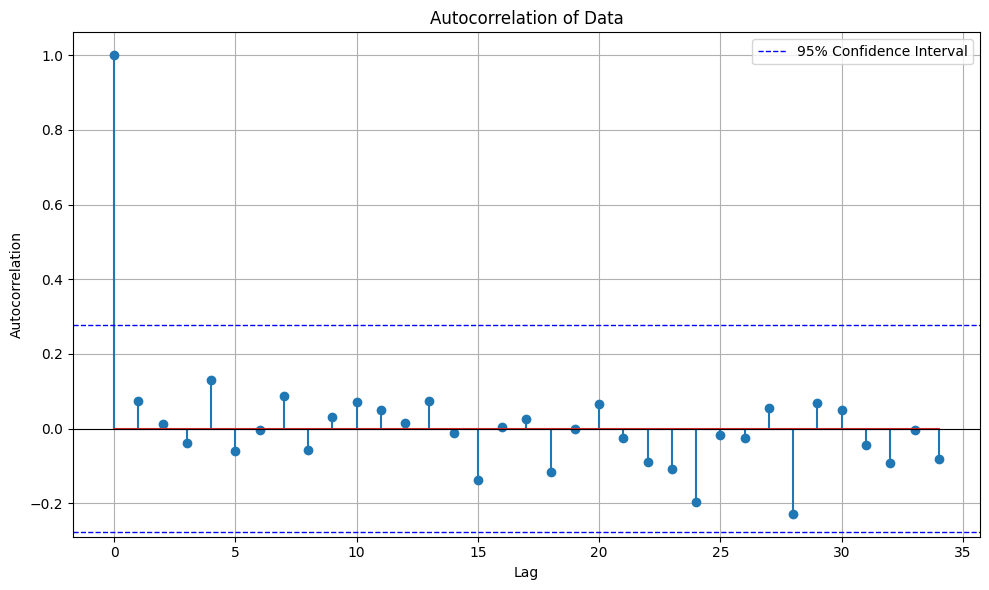

In [1]:
import matplotlib.pyplot as plt
import numpy as np

data = [3, 16, 156, 47, 246, 176, 233, 140, 130, 101, 166, 201, 200, 116, 118,
        247, 209, 52, 153, 232, 128, 27, 192, 168, 208, 187, 228, 86, 30, 151,
        18, 254, 76, 112, 67, 244, 179, 150, 89, 49, 83, 147, 90, 33, 6, 158,
        80, 35, 186, 127]

N = len(data)
lags = range(35)

# Pre-allocate autocorrelation table
autocorr_values = []

# Mean of the data
mean_data = np.mean(data)

# Variance of the data
variance_data = np.var(data)

# Normalize the data
normalized_data = (data - mean_data) / np.sqrt(variance_data)

print(f"N          : {N}")
print(f"Mean       : {mean_data:.4f}")
print(f"Variance   : {variance_data:.4f}")
print(f"Std Dev    : {np.sqrt(variance_data):.4f}")

# Go through lag components one-by-one
for lag in lags:
    if lag == 0:
        autocorr_values.append(1)
    else:
        auto_cov = np.sum((np.array(data[:-lag]) - mean_data) * (np.array(data[lag:]) - mean_data)) / N
        autocorr_values.append(auto_cov / variance_data)

# Display the graph
plt.figure(figsize=(10, 6))
plt.stem(lags, autocorr_values)
plt.title('Autocorrelation of Data')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.axhline(y=1.96/np.sqrt(N), color='blue', linestyle='--', linewidth=1, label='95% Confidence Interval')
plt.axhline(y=-1.96/np.sqrt(N), color='blue', linestyle='--', linewidth=1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()